
📊 Cluster Summary:

              tempo    energy       key  popularity      mode  time_signature  \
cluster                                                                         
0        134.106623  0.752554  5.114381   22.506287  0.628671        3.936999   
1        117.643216  0.633911  5.538583   24.530506  0.581837        3.968825   
2        106.748332  0.204418  4.948189   18.018582  0.684837        3.702626   

         speechiness  danceability   valence  acousticness  liveness  \
cluster                                                                
0           0.077442      0.511640  0.355021      0.124859  0.276743   
1           0.110047      0.696910  0.659819      0.293962  0.153955   
2           0.047720      0.407023  0.242349      0.842784  0.139659   

         instrumentalness  
cluster                    
0                0.246306  
1                0.119746  
2                0.574720  


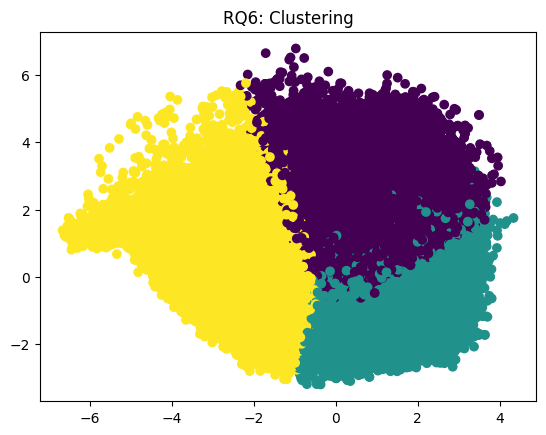

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/tracks.csv")
df = df.select_dtypes(include="number") # First, select only numeric columns
df = df.fillna(df.median()) # Then, fill NaN values using the median of these numeric columns

X = df.drop("popularity", axis=1)
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

cluster_summary = df.groupby("cluster").mean()

print("\n📊 Cluster Summary:\n")
print(cluster_summary)

cluster_summary.to_csv("RQ6_cluster_summary.csv")

# PCA Plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("RQ6: Clustering")
plt.savefig("RQ6_clusters.pdf")
plt.show()